In [ ]:
# Pytorch is typically already installed in Google Colab (uncomment to install):
# !pip install torch==1.8.0
# or for GPU support:
!pip install torch==1.8.0+cu111 -f https://download.pytorch.org/whl/torch_stable.html
!pip install transformers==4.27.0
!pip install datasets==2.10.0
# NLTK is typically also already installed in Google Colab (uncomment to install):
# !pip install nltk==3.8.1

Looking in links: https://download.pytorch.org/whl/torch_stable.html
ERROR: Could not find a version that satisfies the requirement torch==1.8.0+cu111 (from versions: 1.13.0, 1.13.0+cpu, 1.13.0+cu116, 1.13.0+cu117, 1.13.0+cu117.with.pypi.cudnn, 1.13.1, 1.13.1+cpu, 1.13.1+cu116, 1.13.1+cu117, 1.13.1+cu117.with.pypi.cudnn, 2.0.0, 2.0.0+cpu, 2.0.0+cpu.cxx11.abi, 2.0.0+cu117, 2.0.0+cu117.with.pypi.cudnn, 2.0.0+cu118, 2.0.1, 2.0.1+cpu, 2.0.1+cpu.cxx11.abi, 2.0.1+cu117, 2.0.1+cu117.with.pypi.cudnn, 2.0.1+cu118, 2.0.1+rocm5.3, 2.0.1+rocm5.4.2, 2.1.0, 2.1.0+cpu, 2.1.0+cpu.cxx11.abi, 2.1.0+cu118, 2.1.0+cu121, 2.1.0+cu121.with.pypi.cudnn, 2.1.0+rocm5.5, 2.1.0+rocm5.6, 2.1.1, 2.1.1+cpu, 2.1.1+cpu.cxx11.abi, 2.1.1+cu118, 2.1.1+cu121, 2.1.1+cu121.with.pypi.cudnn, 2.1.1+rocm5.5, 2.1.1+rocm5.6, 2.1.2, 2.1.2+cpu, 2.1.2+cpu.cxx11.abi, 2.1.2+cu118, 2.1.2+cu121, 2.1.2+cu121.with.pypi.cudnn, 2.1.2+rocm5.5, 2.1.2+rocm5.6, 2.2.0, 2.2.0+cpu, 2.2.0+cpu.cxx11.abi, 2.2.0+cu118, 2.2.0+cu121, 2.2.0+rocm5.6, 2.2.0

## Download NMT data

We first download the data for NMT, which contains pairs of parallel sentences.

In [ ]:
# !wget --quiet https://princeton-nlp.github.io/cos484/assignments/a4/resources.zip
# !unzip -qo resources.zip
import requests
import zipfile
import io
import os

# Download the zip file
url = "https://princeton-nlp.github.io/cos484/assignments/a4/resources.zip"
response = requests.get(url)

# Check if download was successful
if response.status_code == 200:
    # Extract the zip file
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        z.extractall(".")
    print("Downloaded and extracted resources.zip")
else:
    print(f"Failed to download file: HTTP status code {response.status_code}")

# Verify the extracted folder
if os.path.exists("resources/parallel_en_fr_corpus"):
    print("Dataset folder 'resources/parallel_en_fr_corpus' found")
else:
    print("Dataset folder not found")


Downloaded and extracted resources.zip
Dataset folder 'resources/parallel_en_fr_corpus' found


In [ ]:
# from datasets import load_from_disk
# raw_text_datasets = load_from_disk("resources/parallel_en_fr_corpus")
# print("Summary of splits:", raw_text_datasets)
# print("First training example:", raw_text_datasets["train"][0])
from datasets import Dataset, DatasetDict

# Load each split individually from its Arrow file
train_dataset = Dataset.from_file('resources/parallel_en_fr_corpus/train/dataset.arrow')
validation_dataset = Dataset.from_file('resources/parallel_en_fr_corpus/validation/dataset.arrow')
test_dataset = Dataset.from_file('resources/parallel_en_fr_corpus/test/dataset.arrow')

# Create a DatasetDict from the loaded datasets
raw_text_datasets = DatasetDict({
    'train': train_dataset,
    'validation': validation_dataset,
    'test': test_dataset
})

# Verify the loaded dataset
print("Summary of splits:", raw_text_datasets)
print("First training example:", raw_text_datasets['train'][0])
print("First validation example:", raw_text_datasets['validation'][0])
print("First testing example:", raw_text_datasets['test'][0])

Summary of splits: DatasetDict({
    train: Dataset({
        features: ['text_en', 'text_fr'],
        num_rows: 8701
    })
    validation: Dataset({
        features: ['text_en', 'text_fr'],
        num_rows: 485
    })
    test: Dataset({
        features: ['text_en', 'text_fr'],
        num_rows: 486
    })
})
First training example: {'text_en': 'i m tough .', 'text_fr': 'je suis dure .'}
First validation example: {'text_en': 'she is a most gracious neighbor .', 'text_fr': 'c est une voisine des plus courtoises .'}
First testing example: {'text_en': 'i m trustworthy .', 'text_fr': 'on peut me faire confiance .'}


In [ ]:
from transformers import AutoTokenizer
source_tokenizer = AutoTokenizer.from_pretrained("resources/tokenizer_fr")
target_tokenizer = AutoTokenizer.from_pretrained("resources/tokenizer_en")

print("Vocab size of source language:", source_tokenizer.vocab_size)
print("Vocab size of target language:", target_tokenizer.vocab_size)

# As a demonstration, we will the following English sentence to tokens.
example_sentence = "we have an example"
tokenizer_output = target_tokenizer(example_sentence)
print("\n*** Example ***")
print("Example sentence:", example_sentence)
print("Tokenizer output:", tokenizer_output)

# We convert every token id to its associated string, but find the special character ▁ which indicates the beginning of a word.
# Note that very common words are represented by a single token, while others are split into subunits due to the small vocab size.
# Also note that †he tokenizer already adds special tokens to the beginning and end of the sentence.
decoded_sequence = [target_tokenizer.decode(token) for token in tokenizer_output["input_ids"]]
print("Tokens:", decoded_sequence)

# By replacing the special character ▁ with whitespace, we can reconstruct a legibile sentence,
# which differs from the original example by special tokens, includings <unk> tokens, and minor whitespace differences.
reconstructed = "".join(decoded_sequence).replace("▁", " ")
print("Reconstructed sentence", reconstructed)

Vocab size of source language: 3200
Vocab size of target language: 3200

*** Example ***
Example sentence: we have an example
Tokenizer output: {'input_ids': [1, 64, 324, 103, 266, 1490, 92, 2], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1]}


In [ ]:
from typing import Dict, List

def map_example(example: Dict[str, str]) -> Dict[str, List[int]]:
    """
    Tokenize the source (French) and target (English) text for an entry in the parallel dataset
    and return a dictionary with the keys "encoder_input_ids" and "decoder_input_ids".

    Args:
        example: A dictionary with keys "text_fr" (French text) and "text_en" (English text).

    Returns:
        A dictionary with keys "encoder_input_ids" (tokenized French text) and
        "decoder_input_ids" (tokenized English text), each containing a list of integer token IDs.
    """
    # Tokenize the French source text
    source_tokens = source_tokenizer(example["text_fr"], truncation=True, max_length=32, return_tensors="pt")
    # Tokenize the English target text
    target_tokens = target_tokenizer(example["text_en"], truncation=True, max_length=32, return_tensors="pt")

    return {
        "encoder_input_ids": source_tokens["input_ids"].squeeze().tolist(),
        "decoder_input_ids": target_tokens["input_ids"].squeeze().tolist()
    }

# When mapped is applied to the DatasetDict object, it will apply `map` separately to each split.
tokenized_datasets = raw_text_datasets.map(map_example, batched=False)

# The `remove_columns` removes the existing text features from the new dataset, as they are no longer needed.
tokenized_datasets = tokenized_datasets.remove_columns(raw_text_datasets.column_names["train"])

# Sanity checks on the new dataset
assert set(tokenized_datasets.column_names["train"]) == {"decoder_input_ids", "encoder_input_ids"}
assert len(tokenized_datasets["train"]) == len(raw_text_datasets["train"])

Map:   0%|          | 0/8701 [00:00<?, ? examples/s]

Map:   0%|          | 0/485 [00:00<?, ? examples/s]

Map:   0%|          | 0/486 [00:00<?, ? examples/s]

## Transformer model for NMT

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import math
from typing import Optional, Dict, List, Tuple

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self,
                 hidden_size: int,
                 num_attention_heads: int,
                 is_causal_attention: bool = False,
                 is_cross_attention: bool = False):
        super().__init__()
        # Define the projection layers
        self.W_q = nn.Linear(hidden_size, hidden_size)
        self.W_k = nn.Linear(hidden_size, hidden_size)
        self.W_v = nn.Linear(hidden_size, hidden_size)
        self.W_o = nn.Linear(hidden_size, hidden_size)
        # Set attention head parameters
        self.num_attention_heads = num_attention_heads
        self.is_causal_attention = is_causal_attention
        self.is_cross_attention = is_cross_attention
        # Validate and set head dimension
        assert hidden_size % num_attention_heads == 0, "The hidden size must be divisible by the number of attention heads."
        self.head_dim = hidden_size // num_attention_heads  # Embedding dimension per head

    def causal_attention_mask(self,
                              sequence_length: int,
                              device: Optional[torch.device] = None) -> torch.FloatTensor:
        mask = torch.triu(torch.full((sequence_length, sequence_length), -1e6, device=device), diagonal=1)
        return mask.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, seq_len)
        """Return a Float tensor that can be added to the (un-normalized) attention scores for causal masking.

        Args:
            sequence_length: width and height of the attention mask tensor.
            device: which torch device the resulting tensor should be on (important if you use GPU).

        Returns:
            A Float tensor of shape (1, 1, sequence_length, sequence_length) on device `device`,
            where the entries above the diagonal contain large negative values,
            which means that a query at position i can't attend to a key at position j>i.
        """

        raise NotImplementedError("The forward function in TransformerAttention is not implemented yet.")


    def forward(self,
                hidden_states: torch.FloatTensor,
                key_padding_mask: torch.BoolTensor,
                encoder_outputs: Optional[torch.FloatTensor] = None) -> Tuple[torch.FloatTensor, torch.FloatTensor]:
        batch_size, seq_len, _ = hidden_states.shape
        if self.is_cross_attention:
            assert encoder_outputs is not None, "encoder_outputs required for cross-attention"
            key_value_input = encoder_outputs
            key_len = encoder_outputs.shape[1]
        else:
            key_value_input = hidden_states
            key_len = seq_len

        # Projections
        query = self.W_q(hidden_states)  # (batch_size, seq_len, hidden_size)
        key = self.W_k(key_value_input)  # (batch_size, key_len, hidden_size)
        value = self.W_v(key_value_input)  # (batch_size, key_len, hidden_size)

        # Reshape for heads
        query = query.view(batch_size, seq_len, self.num_attention_heads, self.head_dim).transpose(1, 2)
        key = key.view(batch_size, key_len, self.num_attention_heads, self.head_dim).transpose(1, 2)
        value = value.view(batch_size, key_len, self.num_attention_heads, self.head_dim).transpose(1, 2)

        # Attention scores
        scores = torch.einsum("bnqh,bnkh->bnqk", query, key) / math.sqrt(self.head_dim)

        # Apply padding mask
        if key_padding_mask is not None:
            scores = scores.masked_fill(key_padding_mask.unsqueeze(1).unsqueeze(2), -1e6)

        # Apply causal mask
        if self.is_causal_attention:
            causal_mask = self.causal_attention_mask(seq_len, hidden_states.device)
            scores = scores + causal_mask

        # Attention weights
        attention_weights = F.softmax(scores, dim=-1)

        # Context
        context = torch.einsum("bnqk,bnkh->bnqh", attention_weights, value)
        context = context.transpose(1, 2).contiguous().view(batch_size, seq_len, -1)

        # Output
        output = self.W_o(context)
        return output, attention_weights

        # TODO Implement the forward function.
        # IMPORTANT: For full credit, you should not use python loops. Furthermore,
        #            you are not allowed to use `nn.MultiheadAttention` or `nn.functional.scaled_dot_product_attention`!
        #
        # Hint 1: Use `torch.reshape` to add a new axis for the attention head,
        #         which will allow you to process all attention heads in parallel.
        #
        # Hint 2: You can use `torch.transpose` to swap the order of two axes,
        #         As the attention head dimension should be next to the batch size,
        #         see the shape of the output attention weights.
        #
        # Hint 3: `torch.bmm(matrix1, matrix2)` is useful for computing batched matrix multiplications
        #         If matrix1 has shape (B, M, N) and matrix2 has shape (B, N, P),
        #         it performs `B` matrix multiplications and outputs a tensor of shape (B, M, P).
        #         Alternatively, `torch.einsum` should be very useful.
        #         (We really encourage you to check out the documentation of `torch.einsum`,
        #         it can really make your life easier here.)

        # raise NotImplementedError("The forward function in TransformerAttention is not implemented yet.")

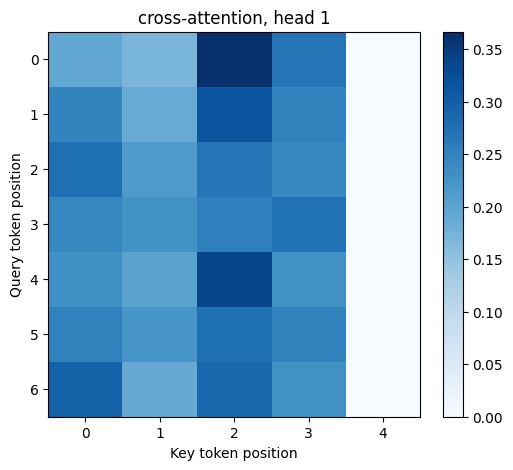

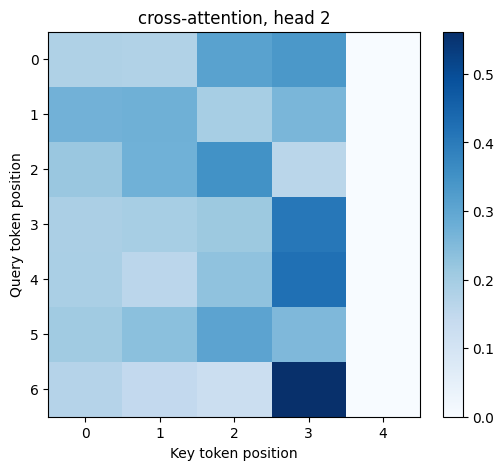

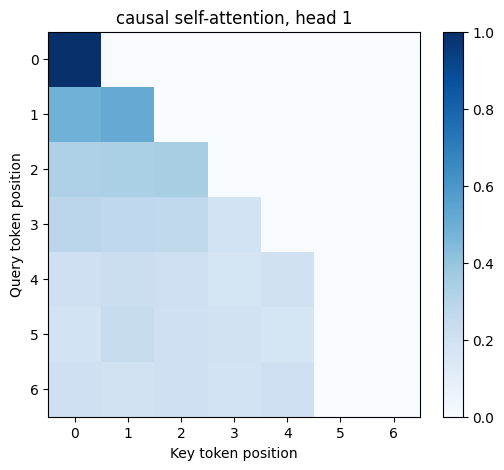

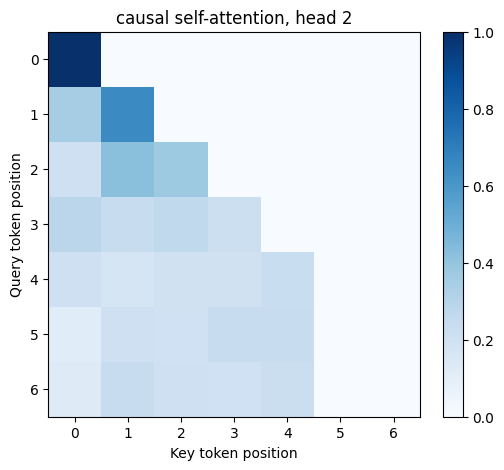

In [ ]:
embed_dim = 8
num_heads = 2
batch_size = 1
encoder_seq_length = 5
decoder_seq_length = 7

encoder_outputs = torch.randn(batch_size, encoder_seq_length, embed_dim)
decoder_inputs = torch.randn(batch_size, decoder_seq_length, embed_dim)

encoder_padding_mask = torch.zeros(batch_size, encoder_seq_length, dtype=torch.bool)
encoder_padding_mask[:, -1] = True # The last encoder token is a padding tokens

decoder_padding_mask = torch.zeros(batch_size, decoder_seq_length, dtype=torch.bool)
decoder_padding_mask[:, -2:] = True # The last two decoder tokens are padding token


cross_attention = MultiHeadAttention(embed_dim, num_heads, is_cross_attention=True)
causal_attention = MultiHeadAttention(embed_dim, num_heads, is_causal_attention=True)

cross_attention_out, cross_attention_weights = cross_attention(decoder_inputs, encoder_padding_mask, encoder_outputs)
causal_attention_out, causal_attention_weights = causal_attention(decoder_inputs, decoder_padding_mask)

# Make sure your outputs have the right hapes
assert cross_attention_out.shape == (batch_size, decoder_seq_length, embed_dim)
assert cross_attention_weights.shape == (batch_size, num_heads, decoder_seq_length, encoder_seq_length)
assert causal_attention_out.shape == (batch_size, decoder_seq_length, embed_dim)
assert causal_attention_weights.shape == (batch_size, num_heads, decoder_seq_length, decoder_seq_length)

# Check that the attention weights are normalized
assert torch.isclose(cross_attention_weights.sum(dim=-1), torch.tensor(1.0)).all()
assert torch.isclose(causal_attention_weights.sum(dim=-1), torch.tensor(1.0)).all()

# Check if the attention masking works
assert torch.isclose(cross_attention_weights[:,:,:,-1], torch.tensor(0.0)).all()
assert torch.isclose(causal_attention_weights[:,:,:,-2:], torch.tensor(0.0)).all()
assert torch.isclose(causal_attention_weights[:,:,2,3:], torch.tensor(0.0)).all()



import matplotlib.pyplot as plt

def plot_attention_matrix(attention_matrix, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(attention_matrix, cmap='Blues', aspect='auto')
    plt.colorbar()
    plt.xlabel("Key token position")
    plt.ylabel("Query token position")
    plt.title(title)
    plt.show()

# Plot the attention weights
plot_attention_matrix(cross_attention_weights[0,0].detach().numpy(), "cross-attention, head 1")
plot_attention_matrix(cross_attention_weights[0,1].detach().numpy(), "cross-attention, head 2")
plot_attention_matrix(causal_attention_weights[0,0].detach().numpy(), "causal self-attention, head 1")
plot_attention_matrix(causal_attention_weights[0,1].detach().numpy(), "causal self-attention, head 2")

In [ ]:
class TransformerEmbeddings(nn.Module):
    def __init__(self, vocab_size: int, hidden_size: int, max_sequence_length: int):
        """Defines the embedding layer with learnt positional embeddings.

        This layer defines both the token embeddings and positional embeddings,
        which are added together to form the final embedding.

        Args:
            vocab_size: The size of the vocabulary,
                    used to define the size of the token embedding table.
            hidden_size: The dimensionality of the embedding space for both token embeddings and positional embeddings.
            max_sequence_length: The maximum sequence length of the input sequences,
                    used to define the size of the position embedding table.

        Note that this implementation does not use dropout on the embeddings
        and uses learnt positional embeddings instead of sinusoidal embeddings.
        """
        super().__init__()
        self.token_embeddings = nn.Embedding(vocab_size, hidden_size)
        self.position_embeddings = nn.Embedding(max_sequence_length, hidden_size)
        self.max_sequence_length = max_sequence_length

        # TODO Initialize the module and its parameters here.
        # You should use `nn.Embedding` for both token embeddings and positional embeddings



    def compute_logits(self, decoder_output: torch.FloatTensor) -> torch.FloatTensor:
        """Computes the logits for the next token prediction given the decoder output.

        Args:
            decoder_output: Tensor of shape (batch_size, sequence_length, hidden_size) - the output of the decoder.

        Returns:
            Tensor of shape (batch_size, sequence_length, vocab_size) containing the logits for the next token prediction.
        """

        # TODO Implement this function
        # Hint: you can access the weight parameter matrix via .weight of an nn.Embedding module:
        # Example:
        # ```embeddings = nn.Embedding(num_embeddings, embedding_dim)
        # assert list(embeddings.weight.shape) == [num_embeddings, embedding_dim]```
        # torch.matmul or F.linear may also be useful here.

        return torch.matmul(decoder_output, self.token_embeddings.weight.t())

    def forward(self, input_ids: torch.LongTensor) -> torch.FloatTensor:
        """Computes the embeddings for the input tokens.

        Args:
            input_ids: Tensor of shape (batch_size, sequence_length) containing the input token ids.

        Returns:
            Tensor of shape (batch_size, sequence_length, hidden_size) containing
                    the sum of token embeddings and position embeddings for the input tokens.
        """

        # TODO Implement the forward pass of the embedding layer.
        # IMPORTANT: For full credit, you should not use python loops!

        batch_size, seq_len = input_ids.shape
        positions = torch.arange(seq_len, device=input_ids.device).unsqueeze(0).expand(batch_size, seq_len)
        token_emb = self.token_embeddings(input_ids)
        position_emb = self.position_embeddings(positions)
        return token_emb + position_emb

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self,
                 hidden_size: int,
                 intermediate_size: int,
                 num_attention_heads: int,
                 hidden_dropout_prob: float,
                 is_decoder: bool = False):
        """Defines a single Transformer block, which can be either for the encoder or the decoder.

        Args:
            hidden_size: The dimensionality of the input and output vectors of this layer.
            intermediate_size: The intermediate size of the feedforward layers.
            num_attention_heads: The number of attention heads.
            hidden_dropout_prob: The dropout probability for the hidden states.
            is_decoder: Whether this block is part of the decoder.
        """
        super().__init__()

        self.is_decoder = is_decoder
        self.self_attention = MultiHeadAttention(hidden_size, num_attention_heads, is_causal_attention=is_decoder)
        self.self_attention_layer_norm = nn.LayerNorm(hidden_size)

        if is_decoder:
            self.cross_attention = MultiHeadAttention(hidden_size, num_attention_heads, is_cross_attention=True)
            self.cross_attention_layer_norm = nn.LayerNorm(hidden_size)

        self.feedforward = nn.Sequential(
            nn.Linear(hidden_size, intermediate_size),
            nn.ReLU(),
            nn.Linear(intermediate_size, hidden_size),
            nn.Dropout(hidden_dropout_prob))
        self.feedforward_layer_norm = nn.LayerNorm(hidden_size)

    def forward(self,
                hidden_states: torch.FloatTensor,
                padding_mask: torch.BoolTensor,
                encoder_outputs: Optional[torch.FloatTensor] = None,
                encoder_padding_mask: Optional[torch.BoolTensor] = None) -> torch.FloatTensor:
        """Defines a single Transformer block, either for the encoder or the decoder.

        Args:
            hidden_states: Tensor of shape (batch_size, sequence_length, hidden_size) - the outputs from the previous layer.
            padding_mask: Tensor of shape (batch_size, sequence_length) indicating which tokens are padding tokens.
                    A `True` entry means that this token should be ignored for the purpose of attention.
            encoder_outputs: Optional tensor of shape (batch_size, encoder_sequence_length, hidden_size),
                    which are the output vectors of the encoder. This argument is only used by decoder blocks.
            encoder_padding_mask: Optional tensor of shape (batch_size, encoder_sequence_length) indicating
                    which encoder tokens are padding tokens. This argument is only used in decoder blocks.
                    A `True` entry means that this token should be ignored for the purpose of attention.

        """
        hidden_states = self.self_attention(hidden_states, padding_mask)[0] + hidden_states
        hidden_states = self.self_attention_layer_norm(hidden_states)

        if self.is_decoder:
            hidden_states = self.cross_attention(hidden_states, encoder_padding_mask, encoder_outputs)[0] + hidden_states
            hidden_states = self.cross_attention_layer_norm(hidden_states)

        hidden_states = self.feedforward(hidden_states) + hidden_states
        hidden_states = self.feedforward_layer_norm(hidden_states)
        return hidden_states

In [ ]:
class EncoderDecoderModel(nn.Module):
    def __init__(self,
                 source_vocab_size: int,
                 target_vocab_size: int,
                 hidden_size: int,
                 intermediate_size: int,
                 num_attention_heads: int,
                 num_encoder_layers: int,
                 num_decoder_layers: int,
                 max_sequence_length: int,
                 hidden_dropout_prob: float):
        """A encoder-decoder transformer model which can be used for NMT.

        Args:
            source_vocab_size: The size of the source vocabulary.
            target_vocab_size: The size of the target vocabulary.
            hidden_size: The dimensionality of all input and output embeddings.
            intermediate_size: The intermediate size in the feedforward layers.
            num_attention_heads: The number of attention heads in each multi-head attention modules.
            num_encoder_layers: The number of transformer blocks in the encoder.
            num_decoder_layers: The number of transformer blocks in the decoder.
            max_sequence_length: The maximum sequence length that this model can handle.
            hidden_dropout_prob: The dropout probability in the hidden state in each block.
        """

        super().__init__()
        self.source_embeddings = TransformerEmbeddings(source_vocab_size, hidden_size, max_sequence_length)
        self.target_embeddings = TransformerEmbeddings(target_vocab_size, hidden_size, max_sequence_length)
        self.encoder_blocks = nn.ModuleList([
            TransformerBlock(hidden_size, intermediate_size, num_attention_heads, hidden_dropout_prob, is_decoder=False)
            for _ in range(num_encoder_layers)
        ])
        self.decoder_blocks = nn.ModuleList([
            TransformerBlock(hidden_size, intermediate_size, num_attention_heads, hidden_dropout_prob, is_decoder=True)
            for _ in range(num_decoder_layers)
        ])

    def forward_encoder(self, input_ids: torch.LongTensor, padding_mask: torch.BoolTensor) -> torch.FloatTensor:
        """Implement the forward pass of the encoder.

        Args:
            input_ids: tensor of shape (batch_size, sequence_length) containing the input token ids to the encoder.
            padding_mask: tensor of shape (batch_size, sequence_length) indicating which encoder tokens are padding tokens (`True`)
                    and should be ignored in self-attention computations.

        Returns:
            Tensor of shape (batch_size, sequence_length, hidden_size) containing the output embeddings of the encoder.
        """
        hidden_states = self.source_embeddings(input_ids)
        for block in self.encoder_blocks:
            hidden_states = block(hidden_states, padding_mask)
        return hidden_states

    def forward_decoder(self,
                        input_ids: torch.LongTensor,
                        padding_mask: torch.BoolTensor,
                        encoder_outputs: torch.FloatTensor,
                        encoder_padding_mask: torch.BoolTensor) -> torch.FloatTensor:
        """Implement the forward pass of the decoder.

        Args:
            input_ids: Tensor of shape (batch_size, sequence_length) containing the input token ids to the decoder.
            padding_mask: Tensor of shape (batch_size, sequence_length) indicating which decoder tokens are padding tokens (`True`)
                    and should be ignored in self-attention computations.
            encoder_outputs: Tensor of shape (batch_size, encoder_sequence_length, hidden_size) containing the output embeddings of the encoder.
            encoder_padding_mask: Tensor of shape (batch_size, encoder_sequence_length) indicating which encoder tokens are padding tokens (`True`)
                    and should be ignored in cross-attention computations.

        Returns:
            Tensor of shape (batch_size, sequence_length, target_vocabulary_size)
            containing the logits for predicting the next token in the target sequence.
        """

        hidden_states = self.target_embeddings(input_ids)
        for block in self.decoder_blocks:
            hidden_states = block(hidden_states, padding_mask, encoder_outputs, encoder_padding_mask)
        logits = self.target_embeddings.compute_logits(hidden_states)
        return logits

    def forward(self, encoder_input_ids, encoder_padding_mask, decoder_input_ids, decoder_padding_mask):
        encoder_outputs = self.forward_encoder(encoder_input_ids, encoder_padding_mask)
        decoder_logits = self.forward_decoder(decoder_input_ids, decoder_padding_mask, encoder_outputs, encoder_padding_mask)
        return decoder_logits

In [ ]:
def collate_fn(examples: List[Dict[str, List[int]]]) -> Dict[str, torch.Tensor]:
    """Collates a list of variable length sequences from the dataset into a batch of pytorch tensors with padding."""
    encoder_sequence_length = max(len(example["encoder_input_ids"]) for example in examples)
    decoder_sequence_length = max(len(example["decoder_input_ids"]) for example in examples)
    batch_size = len(examples)

    encoder_input_ids = torch.full((batch_size, encoder_sequence_length),
                                   fill_value=source_tokenizer.pad_token_id,
                                   dtype=torch.int64)
    encoder_padding_mask = torch.ones((batch_size, encoder_sequence_length),
                                      dtype=torch.bool)

    decoder_input_ids = torch.full((batch_size, decoder_sequence_length),
                                   fill_value=target_tokenizer.pad_token_id,
                                   dtype=torch.int64)
    decoder_padding_mask = torch.ones((batch_size, decoder_sequence_length),
                                      dtype=torch.bool)

    for i, example in enumerate(examples):
        encoder_input_ids[i, :len(example["encoder_input_ids"])] = torch.tensor(example["encoder_input_ids"])
        encoder_padding_mask[i, :len(example["encoder_input_ids"])] = False

        decoder_input_ids[i, :len(example["decoder_input_ids"])] = torch.tensor(example["decoder_input_ids"])
        decoder_padding_mask[i, :len(example["decoder_input_ids"])] = False

    # Calculate statistics for question (b)(ii)
    total_source_tokens = encoder_input_ids.numel()
    source_pad_tokens = (encoder_input_ids == source_tokenizer.pad_token_id).sum().item()
    total_target_tokens = decoder_input_ids.numel()
    target_pad_tokens = (decoder_input_ids == target_tokenizer.pad_token_id).sum().item()

    # print(f"Batch - Source: {total_source_tokens} tokens, {source_pad_tokens / total_source_tokens:.2f} pads")
    # print(f"Batch - Target: {total_target_tokens} tokens, {target_pad_tokens / total_target_tokens:.2f} pads")

    return {"encoder_input_ids": encoder_input_ids,
            "encoder_padding_mask": encoder_padding_mask,
            "decoder_input_ids": decoder_input_ids,
            "decoder_padding_mask": decoder_padding_mask}

In [ ]:
import time
import math

def compute_loss_per_token(model, batch):
    logits = model(**batch)

    valid_label_mask = ~(batch["decoder_padding_mask"][:,1:])
    labels = batch["decoder_input_ids"][:,1:][valid_label_mask]
    logits = logits[:,:-1][valid_label_mask]

    return F.cross_entropy(logits, labels, reduction='none')


def evaluate_perplexity(model, dataset, batch_size=32, device="cpu"):
    model.eval()

    dev_loader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

    num_tokens = loss_sum = 0

    # no_grad() signals backend to throw away all gradients
    with torch.no_grad():
        for batch in dev_loader:
            # Move tensors in batch to device
            for key in batch:
                batch[key] = batch[key].to(device)

            token_losses = compute_loss_per_token(model, batch)

            loss_sum += token_losses.sum()
            num_tokens += token_losses.numel()

        dev_ppl = (loss_sum / num_tokens).exp().cpu().item()
    return dev_ppl




In [ ]:
def train(model, training_dataset, validation_dataset,
          batch_size=32, lr=1e-3, max_epoch=10, log_every=10, valid_niter=100,
          model_path="model.pt"):
    model.train()

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print('Use device: %s' % device)

    model = model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    epoch = global_step = loss_sum = num_tokens = num_examples = 0
    best_valid_perplexity = float('inf')
    train_time = begin_time = time.time()
    print('Beginning maximum likelihood training')


    while True:
        train_loader = torch.utils.data.DataLoader(
            training_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
        epoch += 1
        batches_per_epoch = len(train_loader)
        for i, batch in enumerate(train_loader):
            global_step += 1

            # Move tensors in batch to device
            for key in batch:
                batch[key] = batch[key].to(device)

            optimizer.zero_grad()

            token_losses = compute_loss_per_token(model, batch)
            total_loss = token_losses.sum()

            loss = total_loss / batch_size
            loss.backward()

            optimizer.step()

            loss_sum += total_loss.cpu().item()
            num_tokens += token_losses.numel()
            num_examples += batch_size

            if global_step % log_every == 0:
                average_loss = loss_sum / num_examples
                average_ppl = math.exp(loss_sum / num_tokens)
                print(f"epoch {epoch} ({i}/{batches_per_epoch}) | step {global_step} | "
                      f"avg_nll={average_loss:.2f} avg_ppl={average_ppl:.2f} "
                      f"speed={num_tokens / (time.time() - train_time):.2f} words/sec "
                      f"time_elapsed={time.time() - begin_time:.2f} sec")

                train_time = time.time()
                loss_sum = num_tokens = num_examples = 0.0

            if global_step % valid_niter == 0:
                print('Begin validation ...')
                dev_perplexity = evaluate_perplexity(model, validation_dataset, batch_size=batch_size, device=device)

                print(f"validation: step {global_step} | dev_ppl={dev_perplexity}")

                if dev_perplexity < best_valid_perplexity:
                    best_valid_perplexity = dev_perplexity
                    print(f"epoch {epoch} step {global_step}: save currently the best model to '{model_path}'")
                    torch.save(model.state_dict(), model_path)
                    torch.save(optimizer.state_dict(), model_path + '.optim')
                model.train()

        if epoch == max_epoch:
            print('Reached maximum number of epochs')
            break

In [ ]:
# Set a random seed, so you obtain the same output model if you run this cell again.
# Set a random seed for reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)

# Updated model with increased capacity for better BLEU score
model = EncoderDecoderModel(
    source_vocab_size=source_tokenizer.vocab_size,
    target_vocab_size=target_tokenizer.vocab_size,
    hidden_size=128,  # Increased to 128 for greater capacity
    intermediate_size=128 * 4,  # Adjusted to 512
    num_attention_heads=8,  # Increased to 8 (128 is divisible by 8)
    num_encoder_layers=4,  # Increased to 4 layers
    num_decoder_layers=4,  # Increased to 4 layers
    max_sequence_length=32,
    hidden_dropout_prob=0.1,
)


print("Model architecture:", model)
print("Total number of trainable model parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

train(model, tokenized_datasets["train"], tokenized_datasets["validation"],
      max_epoch=20, model_path="model.pt")

Model architecture: EncoderDecoderModel(
  (source_embeddings): TransformerEmbeddings(
    (token_embeddings): Embedding(3200, 128)
    (position_embeddings): Embedding(32, 128)
  )
  (target_embeddings): TransformerEmbeddings(
    (token_embeddings): Embedding(3200, 128)
    (position_embeddings): Embedding(32, 128)
  )
  (encoder_blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (self_attention): MultiHeadAttention(
        (W_q): Linear(in_features=128, out_features=128, bias=True)
        (W_k): Linear(in_features=128, out_features=128, bias=True)
        (W_v): Linear(in_features=128, out_features=128, bias=True)
        (W_o): Linear(in_features=128, out_features=128, bias=True)
      )
      (self_attention_layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
      (feedforward): Sequential(
        (0): Linear(in_features=128, out_features=512, bias=True)
        (1): ReLU()
        (2): Linear(in_features=512, out_features=128, bias=True)
        (3): D

In [ ]:
from tqdm import tqdm
from nltk.translate.bleu_score import corpus_bleu

def beam_search(model: EncoderDecoderModel,
                encoder_input_ids: torch.LongTensor,
                beam_width: int = 5,
                max_len: int = 32) -> Tuple[torch.LongTensor, float]:
    """Run beam search on the encoder-decoder model for a single source sequence.

    Args:
        model: The encoder-decoder model.
        encoder_input_ids: The input sequence. Tensor of shape [encoder_sequence_length].
        beam_width: Number of generations to expand at each time step.
        max_len: Stop generation when reaching this length for the generated sequence.

    Returns:
        A tuple (generation, score) where generation is the generated target sequence and
            a tensor of shape [target_sequence_length] and score is the corresponding
            log-probability of this generation.
    """
    model.eval()

    encoder_input_ids = encoder_input_ids.unsqueeze(0) # Add the batch dimension
    encoder_padding_mask = torch.zeros_like(encoder_input_ids, dtype=torch.bool) # No padding
    encoder_outputs = model.forward_encoder(encoder_input_ids, encoder_padding_mask)

    generations = [torch.tensor([target_tokenizer.bos_token_id], device=encoder_input_ids.device)]
    scores = [0.0]

    best_generation = None
    best_score = float('-inf')

    for _ in range(max_len):
        new_generations = []
        new_scores = []
        for score, generation in zip(scores, generations):
            generation = generation.unsqueeze(0) # Add the batch dimension
            padding_mask = torch.zeros_like(generation, dtype=torch.bool) # No padding
            decoder_output = model.forward_decoder(generation, padding_mask, encoder_outputs, encoder_padding_mask)
            last_log_probs = decoder_output[0, -1, :].log_softmax(dim=-1)
            top_log_probs, top_indices = last_log_probs.topk(beam_width, dim=-1)

            new_generations.append(torch.cat([generation.expand(beam_width, -1), top_indices[:,None]], dim=1))
            new_scores.append(score + top_log_probs)

        new_generations = torch.cat(new_generations, dim=0)
        new_scores = torch.cat(new_scores, dim=0)

        ends_with_eos = target_tokenizer.eos_token_id == new_generations[:,-1]

        if ends_with_eos.any():
            new_completed_generations = new_generations[ends_with_eos]
            new_completed_scores = new_scores[ends_with_eos]

            if new_completed_scores.max() > best_score:
                best_score = new_completed_scores.max()
                best_generation = new_completed_generations[new_completed_scores.argmax()]

        if best_score >= new_scores.max():
            break

        scores, indices = torch.topk(new_scores, beam_width, dim=-1)
        generations = new_generations[indices]

    if best_generation is None:
        best_generation = generations[0]
        best_score = scores[0]

    return best_generation, best_score.cpu().item()


def run_generation(model, test_dataset, beam_size=5, max_decoding_time_step=32):
    """Run beam search decoding on the test set and compute word-level BLEU."""

    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print('Use device: %s' % device)

    input_sentences = []
    reference_sentences = []
    candidate_sentences = []
    reference_tokens = []
    candidate_tokens = []

    with torch.no_grad():
        for example in tqdm(test_dataset):
            encoder_input_ids = torch.tensor(example["encoder_input_ids"], device=device)

            generation, _ = beam_search(model, encoder_input_ids, beam_size, max_decoding_time_step)

            # Decode given source sequence and generated target sequence and avoid special tokens
            input_text = "".join(source_tokenizer.decode(token).replace("▁", " ") for token in example["encoder_input_ids"][1:-1])
            reference_text = "".join(target_tokenizer.decode(token).replace("▁", " ") for token in example["decoder_input_ids"][1:-1])
            candidate_text = "".join(target_tokenizer.decode(token).replace("▁", " ") for token in generation[1:-1].cpu())

            reference_sentences.append(reference_text)
            candidate_sentences.append(candidate_text)
            reference_tokens.append(reference_text.split())
            candidate_tokens.append(candidate_text.split())
            input_sentences.append(input_text)

    # BLEU expects tokenized sentences; scoring raw strings would score characters.
    bleu_score = corpus_bleu([[reference] for reference in reference_tokens], candidate_tokens)

    return bleu_score, input_sentences, reference_sentences, candidate_sentences

In [ ]:
# Restore the best validation checkpoint
model.load_state_dict(torch.load("model.pt"))

bleu_score, inputs, references, candidates = run_generation(model, tokenized_datasets["test"])
print('\n\nCorpus BLEU: {}'.format(bleu_score * 100))

Use device: cuda:0


100%|██████████| 486/486 [01:21<00:00,  5.95it/s]



Corpus BLEU: 57.663231899567776


In [ ]:
# Feel free to change the range to look at more samples!
for k in range(10, 30):
  print(f"===== Sample {k} =====")
  print(f"Input: {inputs[k]}")
  print(f"Gold: {references[k]}")
  print(f"Pred: {candidates[k]}")

===== Sample 10 =====
Input:  vous me mettez mal a l aise .
Gold:  you re embarrassing me .
Pred:  you re putting me .
===== Sample 11 =====
Input:  c est toi le professeur .
Gold:  you re the teacher .
Pred:  you re the teacher .
===== Sample 12 =====
Input:  elle sourit avec bonheur .
Gold:  she smiled happily .
Pred:  she stared him .
===== Sample 13 =====
Input:  je ne suis pas devin .
Gold:  i m not a psychic .
Pred:  i m not low .
===== Sample 14 =====
Input:  vous allez perdre .
Gold:  you re going to lose .
Pred:  you re going to love it .
===== Sample 15 =====
Input:  vous me touchez .
Gold:  you re touching me .
Pred:  you re fault me .
===== Sample 16 =====
Input:  je pars aujourd hui .
Gold:  i m leaving today .
Pred:  i m today .
===== Sample 17 =====
Input:  je ne suis pas une sainte .
Gold:  i m no saint .
Pred:  i m not a newl .
===== Sample 18 =====
Input:  je suis puissant .
Gold:  i m powerful .
Pred:  i am sorry .
===== Sample 19 =====
Input:  vous n etes qu un lach